# tmp — sep25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [8]:
out_channels = 256
deconv = nn.ConvTranspose2d(8, out_channels, 5)

In [9]:
deconv.weight.shape, deconv.bias.shape

(torch.Size([8, 256, 5, 5]), torch.Size([256]))

In [11]:
bias = nn.Parameter(torch.zeros(out_channels, dtype=torch.float))
bias.shape

torch.Size([256])

In [3]:
import sys, torch, torchvision
print("python:", sys.version)
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "built_cuda?:", torch.backends.cuda.is_built())
print("torchvision:", torchvision.__version__)

python: 3.11.8 | packaged by conda-forge | (main, Feb 16 2024, 20:53:32) [GCC 12.3.0]

torch: 2.8.0+cu128 cuda: 12.8 built_cuda?: True

torchvision: 0.23.0+cu128

In [3]:
trn, vld, _ = make_dataset('DAVIS')

In [4]:
from main.datafeeder import SequenceFeeder

In [5]:
feeder = SequenceFeeder(
    x=vld[0],
    batch_size=123,
    device=device,
)
_ = feeder.get_batch_data(0)

print(feeder)

SequenceFeeder(batch_size=123, iters_per_epoch=195, max_epochs=100, device=cuda:0, seq_len=48)

In [6]:
vid = []
for t in range(feeder.seq_len):
    x_batch, _ = feeder.step()
    vid.append(tonp(x_batch))
vid = np.stack(vid, axis=1)
vid.shape

(123, 48, 1, 32, 32)

In [11]:
np.abs(tonp(feeder.current_x) - vid).mean()

0.0

In [20]:
from utils.animation import show_movie

show_movie(vid[7].squeeze())

## stages schedule shape

In [19]:
n_stages = 4

t_trains = schedule_t_train(
    n_iters=30_000,
    val_init=16,
    val_final=16 * int(2**(n_stages-1)),
    n_stages=n_stages,
    balance_time=False,
    mode='geometric',
    # mode=self.model.cfg.stages_mode,  #'geometric',
)

Counter({16: 7500, 32: 7500, 64: 7500, 128: 7500})

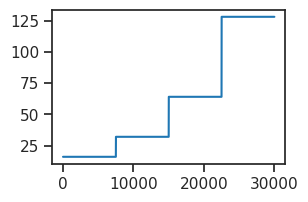

In [20]:
plot(t_trains);
print(collections.Counter(t_trains))

Counter({16: 18718, 53: 5651, 91: 3291, 128: 2340})

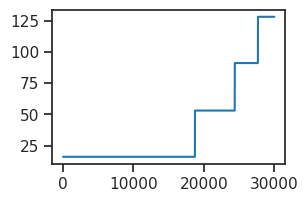

## deconv arithmetic

In [3]:
from base.helper import conv_arithmetic

### Kyoto

### experiment # 1:

main

In [4]:
df = conv_arithmetic(
    deconv=True,
    input_size=8,
    output_size=32,
    stride=3,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      8
1  deconv     False     output_size     32
2  deconv      True     kernel_size     11
3  deconv     False          stride      3
4  deconv     False         padding      0
5  deconv     False  output_padding      0

### experiment # 2:

was worse

In [5]:
df = conv_arithmetic(
    deconv=True,
    input_size=9,
    output_size=32,
    stride=3,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      9
1  deconv     False     output_size     32
2  deconv      True     kernel_size      8
3  deconv     False          stride      3
4  deconv     False         padding      0
5  deconv     False  output_padding      0

### experiment # 3:

TODO: observe results from fit_2

In [12]:
df = conv_arithmetic(
    deconv=True,
    input_size=7,
    output_size=32,
    stride=3,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      7
1  deconv     False     output_size     32
2  deconv      True     kernel_size     14
3  deconv     False          stride      3
4  deconv     False         padding      0
5  deconv     False  output_padding      0

### experiment # 4:

TODO: observe results from fit_3

In [14]:
df = conv_arithmetic(
    deconv=True,
    input_size=6,
    output_size=32,
    stride=3,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      6
1  deconv     False     output_size     32
2  deconv      True     kernel_size     17
3  deconv     False          stride      3
4  deconv     False         padding      0
5  deconv     False  output_padding      0

### MNIST

In [6]:
df = conv_arithmetic(
    deconv=True,
    input_size=8,
    output_size=28,
    stride=3,
)
print(df)

mode  computed       parameter  value
0  deconv     False      input_size      8
1  deconv     False     output_size     28
2  deconv      True     kernel_size      7
3  deconv     False          stride      3
4  deconv     False         padding      0
5  deconv     False  output_padding      0